# I. Mục tiêu
Xác định mô hình dự đoán phù hợp cho bài toán Price Forecasting trong ngắn hạn (T+1, T+2, T+3) khi dùng cùng một input config data.

- Input: Giá đóng cửa 10 ngày gần nhất

- Output: Giá đóng cửa 3 ngày tiếp theo

- Feature engineering cơ bản: chuẩn hóa Min-Max, dùng chuỗi giá đóng cửa kết hợp chỉ báo RSI(14) và SMA(20) tại thời điểm gần nhất

# II. Phương pháp thực hiện:

1. Data Collect: Thu thập và lọc dữ liệu theo mã ACB, sau đó xử lý thời gian và loại bỏ giá trị thiếu.

2. Feature Engineering: Tạo đặc trưng kỹ thuật (RSI, SMA), xây dựng chuỗi supervised learning với input 10 ngày và output 3 ngày.

3. Data Splitting: Chia tập train-test theo thời gian (252 ngày cuối sử dụng cho test) và huấn luyện 3 mô hình: SVM, ANN, ARIMA.

4. Training Strategy: Dùng cơ chế walk-forward với refit định kỳ 7 ngày để dự báo trên tập test.

5. Results: So sánh kết quả bằng các chỉ số MAE, RMSE, MAPE, R2 và Directional Accuracy (DA) + Mô tả trực quan qua 4 biểu đồ.

In [1]:
import pandas as pd
from vnstock import Vnstock  # <-- Đổi import sang class Vnstock
from datetime import datetime

# 1. Danh sách các mã trong rổ VN30
vn30_tickers = [
    'ACB', 'FPT', 'HPG','VIC', 'VJC'
]

# 2. Cấu hình thời gian
start_date = '2015-01-01'
end_date = datetime.now().strftime('%Y-%m-%d') # Lấy đến ngày hôm nay

print(f"Đang tải dữ liệu từ {start_date} đến {end_date}...")
all_data = pd.DataFrame()

# 3. Vòng lặp tải và gộp dữ liệu
for symbol in vn30_tickers:
    try:
        # --- ĐOẠN SỬA ĐỔI THEO CÁCH MỚI ---
        # Khởi tạo đối tượng stock với nguồn dữ liệu (ở đây dùng VCI cho ổn định)
        stock = Vnstock().stock(symbol=symbol, source='VCI')
        
        # Lấy dữ liệu lịch sử (thay thế hàm stock_historical_data cũ)
        # resolution='1D' cũ -> đổi thành interval='1D'
        df = stock.quote.history(start=start_date, end=end_date, interval='1D')
        # ----------------------------------

        if df is not None and not df.empty:
            df['Ticker'] = symbol  # Thêm cột Ticker để phân biệt
            all_data = pd.concat([all_data, df], ignore_index=True)
            print(f"✓ Đã tải: {symbol} ({len(df)} dòng)")
        else:
            print(f"⚠ Không có dữ liệu trả về cho: {symbol}")
            
    except Exception as e:
        print(f"✕ Lỗi {symbol}: {e}")

# 4. Lưu file CSV
file_name = f'VN30_Dataset_{start_date}_{end_date}.csv'
# Kiểm tra nếu có dữ liệu mới lưu
if not all_data.empty:
    all_data.to_csv(file_name, index=False)
    print(f"\nHoàn tất! Dữ liệu đã được lưu vào file: {file_name}")
    print(f"Tổng số dòng dữ liệu: {len(all_data)}")
else:
    print("\nKhông tải được dữ liệu nào. Vui lòng kiểm tra kết nối mạng hoặc nguồn dữ liệu.")

Version Vnstock 3.5.0 is available. Please update using: `pip install vnstock --upgrade`.
Release history: https://vnstocks.com/docs/tai-lieu/lich-su-phien-ban
Current version: 3.3.1

Version Vnai 2.4.0 is available. Please update using: `pip install vnai --upgrade`.
Release history: https://pypi.org/project/vnai/#history
Current version: 2.2.6

Đang tải dữ liệu từ 2015-01-01 đến 2026-04-02...
✓ Đã tải: ACB (2938 dòng)
✓ Đã tải: FPT (2938 dòng)
✓ Đã tải: HPG (2938 dòng)
✓ Đã tải: VIC (2938 dòng)
✓ Đã tải: VJC (2273 dòng)

Hoàn tất! Dữ liệu đã được lưu vào file: VN30_Dataset_2015-01-01_2026-04-02.csv
Tổng số dòng dữ liệu: 14025


In [2]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR

from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
np.random.seed(42)

In [3]:
# ==============================
# CẤU HÌNH
# ==============================

#DATA_PATH = Path("../../data/VN30_Dataset_2015_2026.csv")
DATA_PATH = Path(f"VN30_Dataset_{start_date}_{end_date}.csv")
OUTPUT_DIR = Path("./outputs")
MODEL_DIR = OUTPUT_DIR / "models"

# Số ngày sử dụng để dự báo
WINDOW_SIZE = 10

# Số ngày dự báo
FORECAST_DAYS = 3

# Số bước refit mô hình (Refit mỗi 5 ngày)
REFIT_STEP = 7

# Cổ phiếu Bluechip, độ ổn định cao
TICKER = "ACB"

# Baseline ARIMA order tiêu chuẩn
# Thường được sử dụng trong nghiên cứu về dự báo chuỗi thời gian tài chính
ARIMA_ORDER = (2, 1, 2)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print(DATA_PATH.resolve())

/media/trantrongdat/DATA/Master/hocky1/phantichdulieulon/PTDLL-SVM-ANN-ARIMA-Stock-Price-Forcasting/VN30_Dataset_2015-01-01_2026-04-02.csv


In [4]:
# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv(DATA_PATH)

df["time"] = pd.to_datetime(df["time"], errors="coerce")
df = df.dropna(subset=["time", "close", "Ticker"]).sort_values(["Ticker", "time"]).reset_index(drop=True)
counts = df.groupby("Ticker").size().sort_values(ascending=False)

selected_tickers = TICKER
print("Rows:", len(df), "Tickers:", selected_tickers)


Rows: 14025 Tickers: ACB


In [5]:
def add_features(df):
    # ==============================
    # Feature Engineering
    # ==============================
    out = df.copy()
    out["SMA20"] = out["close"].rolling(20).mean()

    delta = out["close"].diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    out["RSI_14"] = 100 - (100 / (1 + (gain / loss)))

    return out.dropna().reset_index(drop=True)

def create_sequence(df):
    # ==============================
    # TẠO X (Ngày quá khứ) & Y (Ngày tương lai)
    # ==============================
    close = df["close"].values.astype(float)
    rsi = df["RSI_14"].values.astype(float)
    sma = df["SMA20"].values.astype(float)

    X, y, anchors = [], [], []

    for i in range(WINDOW_SIZE, len(close) - FORECAST_DAYS + 1):

        past_prices = close[i-WINDOW_SIZE:i]
        latest_rsi = rsi[i-1]
        latest_sma = sma[i-1]

        X.append(np.concatenate([past_prices, [latest_rsi, latest_sma]]))
        y.append(close[i:i+FORECAST_DAYS])
        anchors.append(i)

    return np.array(X), np.array(y), np.array(anchors), close

def evaluate(y_true, y_pred, prev):
    # ==============================
    # ĐÁNH GIÁ MÔ HÌNH
    # ==============================

    mae_l, rmse_l, mape_l, r2_l, da_l = [], [], [], [], []
    for d in range(FORECAST_DAYS):

        yt, yp = y_true[:, d], y_pred[:, d]

        # MAE - Mean Absolute Error
        mae = mean_absolute_error(yt, yp)
        mae_l.append(mae)

        # RMSE - Root Mean Squared Error
        rmse = np.sqrt(mean_squared_error(yt, yp))
        rmse_l.append(rmse)

        # MAPE - Mean Absolute Percentage Error
        mape = np.mean(np.abs((yt - yp) / yt)) * 100
        mape_l.append(mape)

        # R2 - Coefficient of Determination
        r2 = r2_score(yt, yp)
        r2_l.append(r2)

        # DA - Directional Accuracy
        da = np.mean(np.sign(yt - prev) == np.sign(yp - prev))
        da_l.append(da)

    return {
        "MAE": float(np.mean(mae_l)),
        "RMSE": float(np.mean(rmse_l)),
        "MAPE": float(np.mean(mape_l)),
        "R2": float(np.mean(r2_l)),
        "DA": float(np.mean(da_l)),
    }

In [ ]:
def predict_svm(X_train, y_train, X_test, y_test, refit_step=REFIT_STEP):
    # =====================================
    # Training model SVM với MultiOutputRegressor để dự báo 3 ngày tiếp theo
    # =====================================

    # --- Khởi tạo GridSearch trên toàn bộ tập huấn luyện để tìm hyperparameter tốt nhất ---
    sx0, sy0 = MinMaxScaler(), MinMaxScaler()
    X_tr_s = sx0.fit_transform(X_train)
    y_tr_s = sy0.fit_transform(y_train)

    base_svr = SVR(kernel="rbf")
    grid = GridSearchCV(
        MultiOutputRegressor(base_svr),
        {
            "estimator__C": [1, 10, 100],
            "estimator__gamma": [0.1, 0.01],
            "estimator__epsilon": [0.01],
        },
        cv=TimeSeriesSplit(n_splits=3),
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )
    grid.fit(X_tr_s, y_tr_s)

    # --- Walk-forward loop ---
    X_so_far = X_train
    y_so_far = y_train
    all_preds = []
    last_model, last_sx, last_sy = None, None, None

    for start in range(0, len(X_test), refit_step):
        # --- Thực hiện refit mô hình mỗi refit_step ---

        end = min(start + refit_step, len(X_test))

        sx, sy = MinMaxScaler(), MinMaxScaler()
        X_so_far_s = sx.fit_transform(X_so_far)
        y_so_far_s = sy.fit_transform(y_so_far)

        # Train model (refit)
        model = grid.best_estimator_
        model.fit(X_so_far_s, y_so_far_s)

        # Dự đoán và append kết quả
        X_chunk_s = sx.transform(X_test[start:end])
        y_chunk_pred = sy.inverse_transform(model.predict(X_chunk_s))
        all_preds.append(y_chunk_pred)

        # Bổ sung dữ liệu tập test (đã dự đoán) vào tập train để refit ở bước tiếp theo
        X_so_far = np.vstack([X_so_far, X_test[start:end]])
        y_so_far = np.vstack([y_so_far, y_test[start:end]])

        last_model, last_sx, last_sy = model, sx, sy

    return np.vstack(all_preds), last_model, last_sx, last_sy


def predict_ann(X_train, y_train, X_test, y_test, refit_step=REFIT_STEP):
    # =====================================
    # Training model ANN với MLPRegressor để dự báo 3 ngày tiếp theo
    # =====================================
    X_so_far = X_train
    y_so_far = y_train
    all_preds = []
    last_model, last_sx, last_sy = None, None, None

    for start in range(0, len(X_test), refit_step):
        # --- Thực hiện refit mô hình mỗi refit_step ---
        end = min(start + refit_step, len(X_test))

        sx, sy = MinMaxScaler(), MinMaxScaler()
        X_so_far_s = sx.fit_transform(X_so_far)
        y_so_far_s = sy.fit_transform(y_so_far)

        ann = MLPRegressor(
            # --- Architecture ---
            hidden_layer_sizes=(128, 64),   # 2 hidden layers: layer 1 có 128 neurons, layer 2 có 64 neurons
            activation='relu',              # Hàm kích hoạt cho các hidden layers

            # --- Solver (Thuật toán tối ưu) ---
            solver='adam',                  # Thuật toán cập nhật trọng số (weight)
                                            # adam = Adaptive Moment Estimation: tự điều chỉnh learning rate
            alpha=0.0001,                   # Hệ số L2 regularization: phạt các trọng số lớn
            batch_size='auto',              # Số mẫu dùng cho mỗi lần cập nhật trọng số

            # --- Training (Huấn luyện) ---
            max_iter=200,                   # Số epoch tối đa (1 epoch = duyệt qua toàn bộ tập train 1 lần)
            shuffle=False,                  # Sử dụng = False với time series, vì thứ tự thời gian cần được bảo toàn

            # --- Early Stopping ---
            early_stopping=True,            # Tránh overfitting. Tự động dừng huấn luyện khi val_loss không cải thiện
            validation_fraction=0.1,        # 10% cuối tập train được tách ra làm validation set
        )
        ann.fit(X_so_far_s, y_so_far_s)

        X_chunk_s = sx.transform(X_test[start:end])
        y_chunk_pred = sy.inverse_transform(ann.predict(X_chunk_s))
        all_preds.append(y_chunk_pred)

        # Bổ sung dữ liệu tập test (đã dự đoán) vào tập train để refit ở bước tiếp theo
        X_so_far = np.vstack([X_so_far, X_test[start:end]])
        y_so_far = np.vstack([y_so_far, y_test[start:end]])

        last_model, last_sx, last_sy = ann, sx, sy

    return np.vstack(all_preds), last_model, last_sx, last_sy


def predict_arima(close_values, anchors, refit_step=REFIT_STEP):
    # =====================================
    # Training model ARIMA để dự báo 3 ngày tiếp theo
    # =====================================
    out = []
    fitted = None

    for i, anchor in enumerate(anchors):
        anchor = int(anchor)

        # --- Thực hiện refit mô hình mỗi refit_step ---
        if i % refit_step == 0 or fitted is None:
            history = close_values[:anchor]
            try:
                fitted = ARIMA(history, order=ARIMA_ORDER).fit()
            except Exception:
                fitted = ARIMA(history, order=(1, 1, 0)).fit()
        # else:
        #     # Update model with one new observation since last anchor
        #     fitted = fitted.append(close_values[anchor - 1:anchor])

        # Dự báo 3 ngày tiếp theo
        forecast = fitted.forecast(steps=FORECAST_DAYS)
        out.append(forecast)

    return np.array(out)

In [7]:
all_metrics = []

tdf = add_features(df[df["Ticker"] == selected_tickers])

X, y, anchors, close_values = create_sequence(tdf)
#test_size = int(len(X) * 0.2)
test_size = 252

X_train, X_test = X[:-test_size], X[-test_size:]
y_train, y_test = y[:-test_size], y[-test_size:]
anchors_test = anchors[-test_size:]
prev = X_test[:, WINDOW_SIZE - 1]

y_svm, svm_model, svm_sx, svm_sy = predict_svm(X_train, y_train, X_test, y_test)
y_ann, ann_model, ann_sx, ann_sy = predict_ann(X_train, y_train, X_test, y_test)
y_arima = predict_arima(close_values, anchors_test)

pred_map = {"SVM": y_svm, "ANN": y_ann, "ARIMA": y_arima}
for name, yp in pred_map.items():
    m = evaluate(y_test, yp, prev)
    m["Ticker"] = selected_tickers
    m["Model"] = name
    all_metrics.append(m)

joblib.dump(svm_model, MODEL_DIR / f"svm_multi_{selected_tickers}.pkl")
joblib.dump(svm_sx, MODEL_DIR / f"svm_scaler_X_{selected_tickers}.pkl")
joblib.dump(svm_sy, MODEL_DIR / f"svm_scaler_y_{selected_tickers}.pkl")
joblib.dump(ann_model, MODEL_DIR / f"ann_multi_{selected_tickers}.pkl")
joblib.dump(ann_sx, MODEL_DIR / f"ann_scaler_X_{selected_tickers}.pkl")
joblib.dump(ann_sy, MODEL_DIR / f"ann_scaler_y_{selected_tickers}.pkl")

metrics_df = pd.DataFrame(all_metrics)
metrics_by_model = metrics_df.groupby("Model")[["MAE", "RMSE", "MAPE", "R2", "DA"]].mean().sort_values("MAE").reset_index()
metrics_df.to_csv(OUTPUT_DIR / "model_metrics_comparison.csv", index=False)
metrics_by_model

,Model,MAE,RMSE,MAPE,R2,DA
0,SVM,0.386664,0.586104,1.631336,0.918957,0.444444
1,ANN,0.546604,0.795759,2.290246,0.854435,0.428571
2,ARIMA,0.594365,0.812821,2.471283,0.848976,0.428571


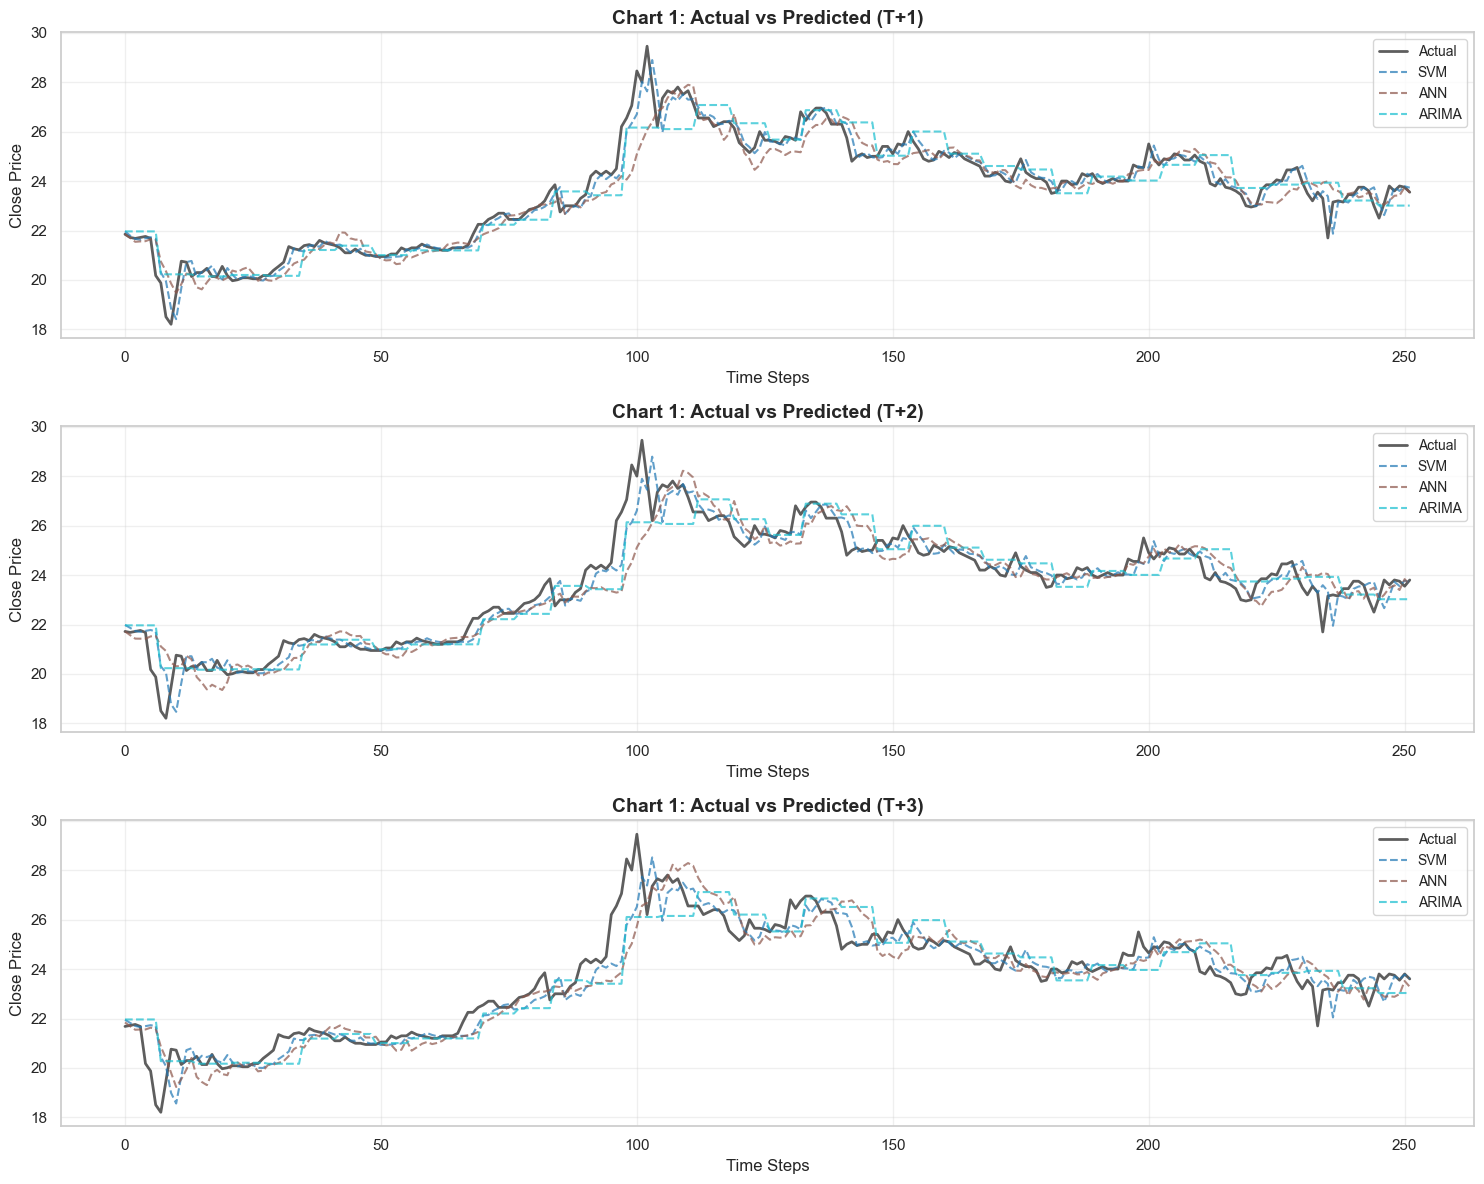

In [8]:
# Chart 1: Actual vs Predicted (T+1, T+2, T+3) - evaluation.py style
output_labels = ["T+1", "T+2", "T+3"]
n_outputs = y_test.shape[1]

fig, axes = plt.subplots(n_outputs, 1, figsize=(15, 4 * n_outputs))
if n_outputs == 1:
    axes = [axes]

x = np.arange(len(y_test))
colors = plt.cm.tab10(np.linspace(0, 1, len(pred_map)))

for i in range(n_outputs):
    axes[i].plot(x, y_test[:, i], 'k-', label='Actual', linewidth=2, alpha=0.7)

    for (model_name, y_pred), color in zip(pred_map.items(), colors):
        axes[i].plot(x, y_pred[:, i], '--', label=model_name, linewidth=1.5, alpha=0.7, color=color)

    horizon_label = output_labels[i] if i < len(output_labels) else f"Output {i + 1}"
    axes[i].set_xlabel('Time Steps', fontsize=12)
    axes[i].set_ylabel('Close Price', fontsize=12)
    axes[i].set_title(f'Chart 1: Actual vs Predicted ({horizon_label})', fontsize=14, fontweight='bold')
    axes[i].legend(loc='best', fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Cả 3 mô hình đều bám được xu hướng chung của chuỗi thực tế ở cả T+1, T+2 và T+3, cho thấy khả năng học mức giá tương đối tốt trong ngắn hạn.

- SVM cho đường dự báo bám sát đường Actual nhất ở đa số giai đoạn, đặc biệt khi thị trường chuyển trạng thái nhanh (vùng giảm sâu đầu chuỗi và vùng tăng mạnh quanh mốc ~100).

- ANN theo được xu hướng nhưng độ lệch cục bộ lớn hơn SVM tại một số điểm đảo chiều, thể hiện hiện tượng làm mượt và phản ứng chậm hơn.

- ARIMA tạo quỹ đạo dạng bậc thang rõ rệt do cơ chế forecast/refit, nên có độ trễ nhất định khi chuỗi biến động ngắn hạn.

- Quan sát trực quan này phù hợp với kết quả định lượng ở Chart 2: SVM có lỗi trung bình thấp hơn và R2 cao hơn hai mô hình còn lại.

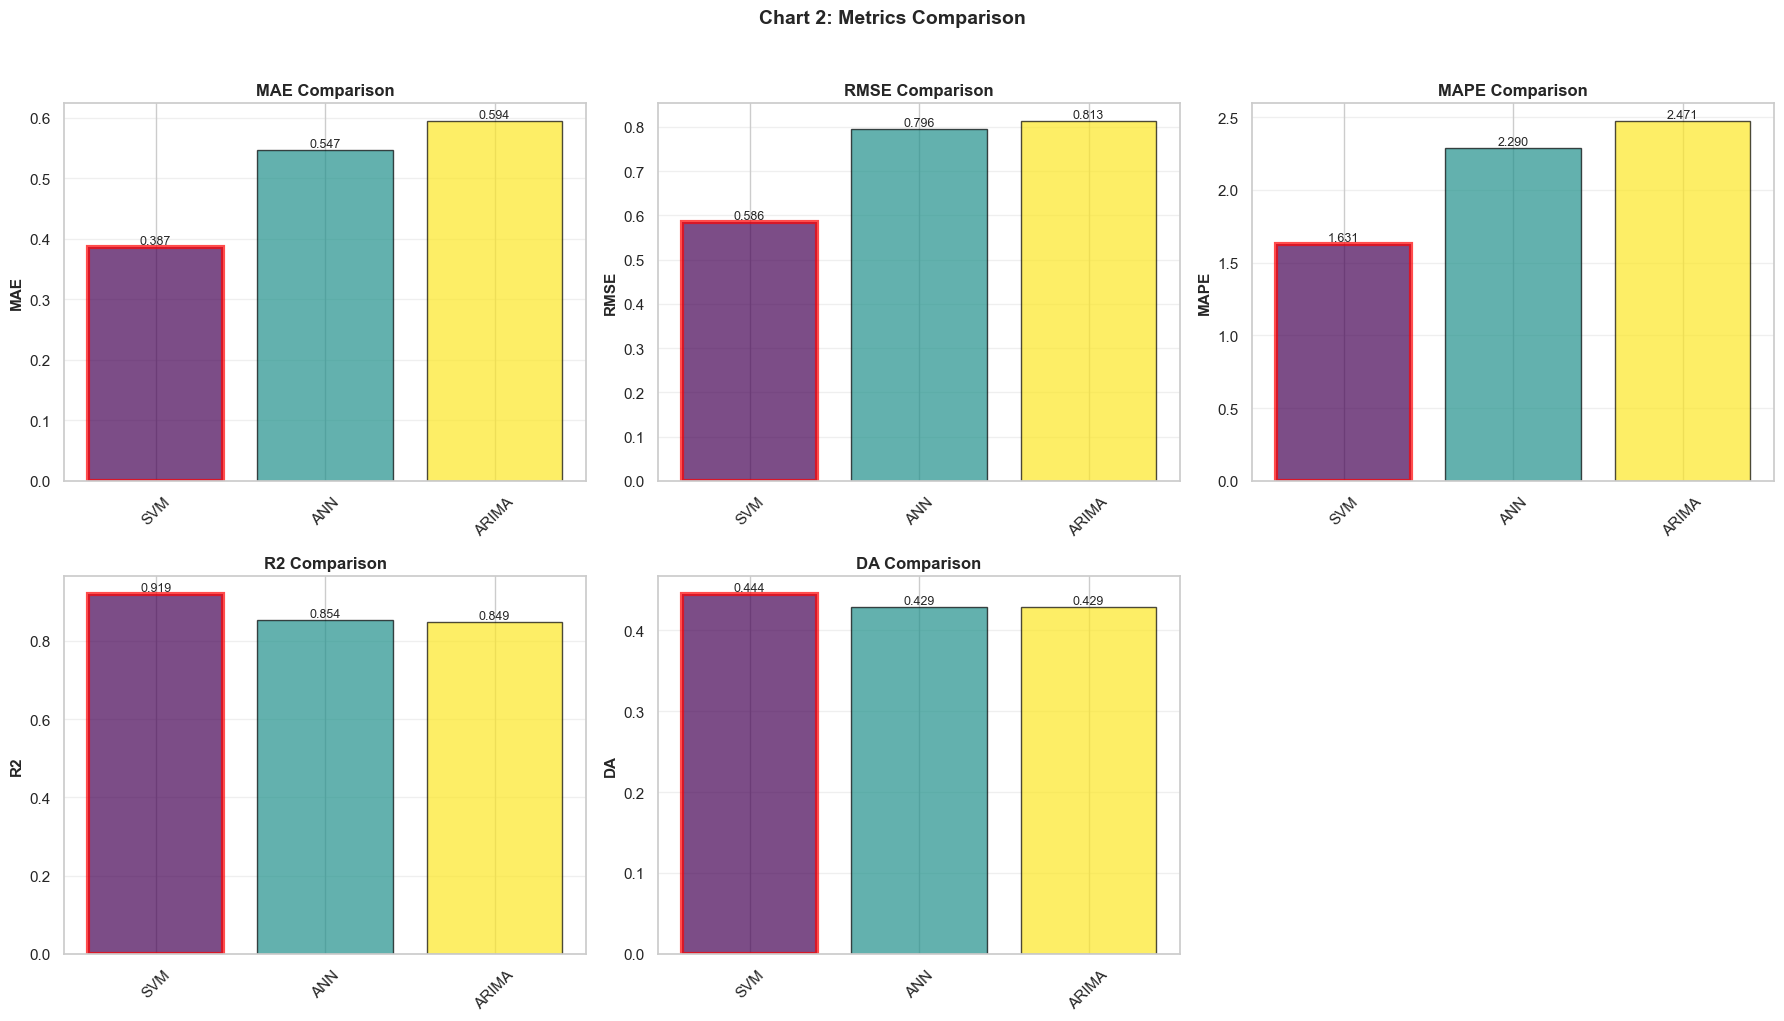

In [9]:
# Chart 2: Metrics Comparison - evaluation.py style
metrics_to_plot = ["MAE", "RMSE", "MAPE", "R2", "DA"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]

    values = metrics_by_model[metric].values
    models = metrics_by_model["Model"].tolist()

    colors = plt.cm.viridis(np.linspace(0, 1, len(models)))
    bars = ax.bar(models, values, color=colors, alpha=0.7, edgecolor='black')

    # Highlight best model
    if metric in ["MAE", "RMSE", "MAPE"]:
        best_idx = np.argmin(values)
    else:
        best_idx = np.argmax(values)

    bars[best_idx].set_edgecolor("red")
    bars[best_idx].set_linewidth(3)

    ax.set_ylabel(metric, fontsize=11, fontweight='bold')
    ax.set_title(f"{metric} Comparison", fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2.0,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

# Remove extra subplot
fig.delaxes(axes[-1])

fig.suptitle("Chart 2: Metrics Comparison", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

- SVM là mô hình tốt nhất ở toàn bộ 5 chỉ số trong test này: MAE = 0.387, RMSE = 0.586, MAPE = 1.632, R2 = 0.919, DA = 0.444.

- ANN đứng thứ hai về sai số và độ giải thích: MAE = 0.546, RMSE = 0.796, MAPE = 2.290, R2 = 0.854, DA = 0.429.

- ARIMA cho kết quả thấp nhất trong ba mô hình ở bộ chỉ số hiện tại: MAE = 0.594, RMSE = 0.813, MAPE = 2.471, R2 = 0.849, DA = 0.429.

- Chênh lệch giữa ANN và ARIMA không lớn ở R2/DA, nhưng SVM tạo khoảng cách tương đối rõ ở cả nhóm sai số lẫn mức độ giải thích phương sai.

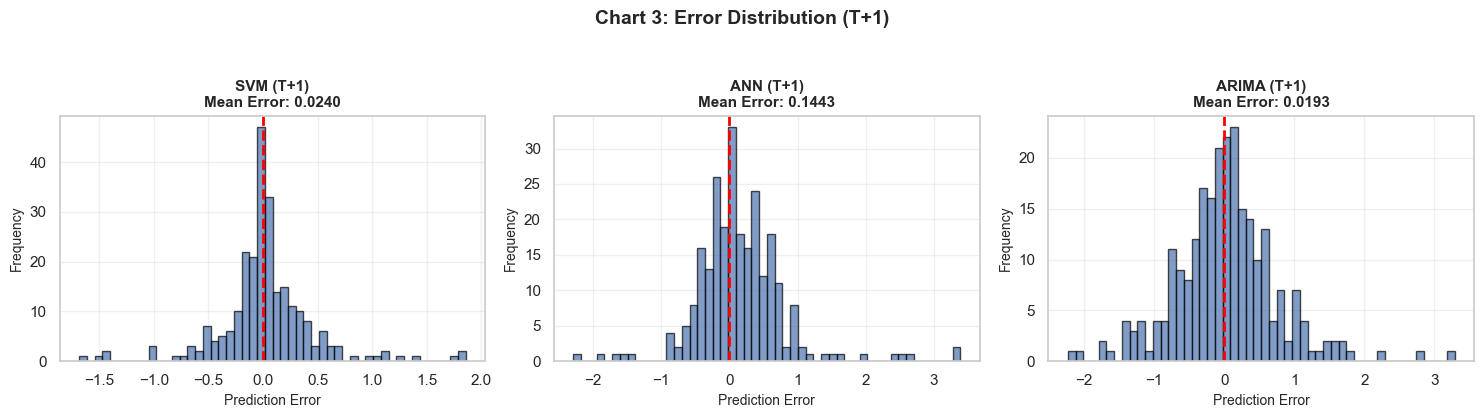

In [10]:
# Chart 3: Error Distribution (T+1) - evaluation.py style
n_models = len(pred_map)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4))

if n_models == 1:
    axes = [axes]

for ax, (model_name, y_pred) in zip(axes, pred_map.items()):
    errors = y_test[:, 0] - y_pred[:, 0]

    ax.hist(errors, bins=50, alpha=0.7, edgecolor="black")
    ax.axvline(0, color="red", linestyle="--", linewidth=2)
    ax.set_xlabel("Prediction Error", fontsize=10)
    ax.set_ylabel("Frequency", fontsize=10)
    ax.set_title(
        f"{model_name} (T+1)\nMean Error: {np.mean(errors):.4f}",
        fontsize=11,
        fontweight="bold"
    )
    ax.grid(True, alpha=0.3)

plt.suptitle("Chart 3: Error Distribution (T+1)", fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

- Phân phối sai số T+1 của cả 3 mô hình đều tập trung quanh 0, cho thấy phần lớn dự báo không lệch quá xa giá trị thực.

- Mean Error lần lượt là: SVM = 0.0240, ANN = 0.1443, ARIMA = 0.0193. Tất cả đều dương, nghĩa là trung bình các mô hình có xu hướng dự báo thấp hơn thực tế (under-predict), trong đó ANN lệch nhiều nhất.

- Histogram của SVM hẹp và cân bằng hơn, thể hiện sai số ổn định hơn so với ANN và ARIMA.

- ANN có đuôi phải dài hơn (xuất hiện một số sai số dương lớn), cho thấy rủi ro bỏ lỡ các nhịp tăng mạnh.

- ARIMA có mean gần 0 nhất nhưng độ phân tán vẫn rộng và có một số ngoại lệ lớn, nên độ ổn định tổng thể vẫn kém hơn SVM.

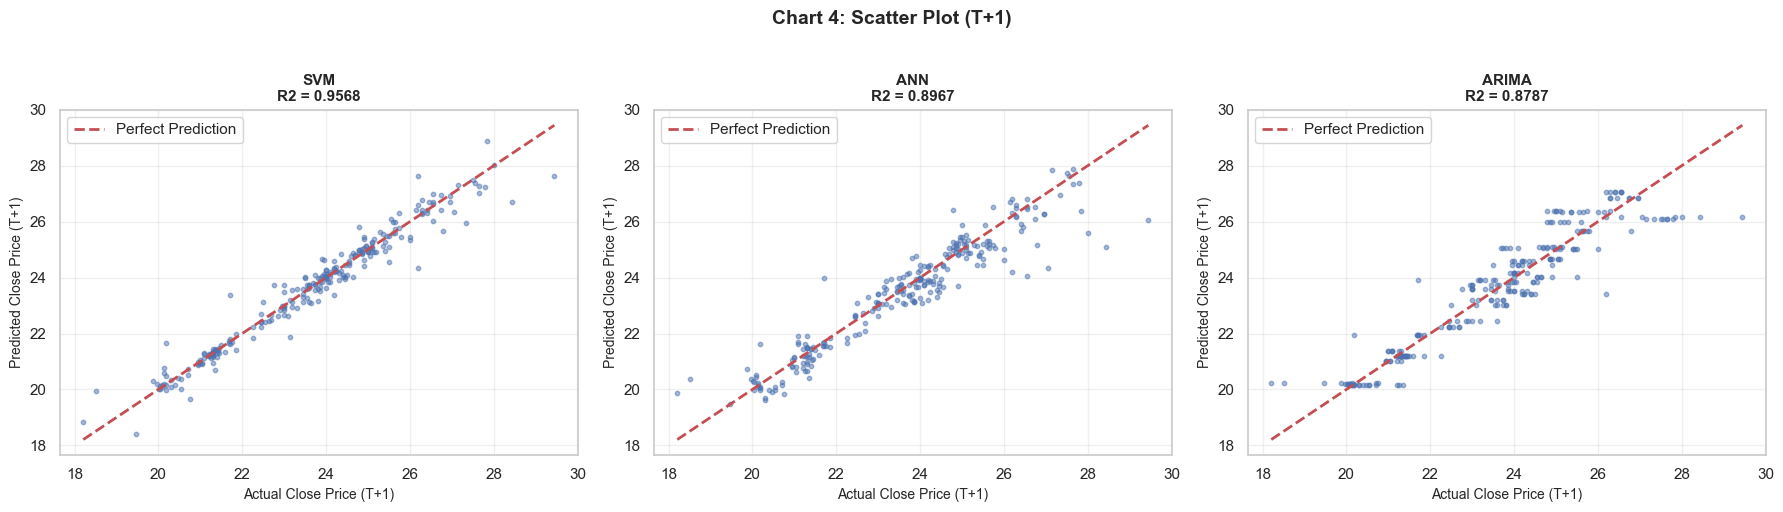

In [43]:
# Chart 4: Scatter Plot (Actual vs Predicted, T+1) - evaluation.py style
n_models = len(pred_map)
cols = min(3, n_models)
rows = (n_models + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))

if n_models == 1:
    axes = [axes]
else:
    axes = np.array(axes).flatten()

y_true_t1 = y_test[:, 0]

for ax, (model_name, y_pred) in zip(axes, pred_map.items()):
    y_pred_t1 = y_pred[:, 0]

    ax.scatter(y_true_t1, y_pred_t1, alpha=0.5, s=10)

    # Perfect prediction reference line
    min_val = min(y_true_t1.min(), y_pred_t1.min())
    max_val = max(y_true_t1.max(), y_pred_t1.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

    ax.set_xlabel('Actual Close Price (T+1)', fontsize=10)
    ax.set_ylabel('Predicted Close Price (T+1)', fontsize=10)
    ax.set_title(
        f"{model_name}\nR2 = {r2_score(y_true_t1, y_pred_t1):.4f}",
        fontsize=11,
        fontweight='bold'
    )
    ax.legend()
    ax.grid(True, alpha=0.3)

# Remove extra subplots
for idx in range(n_models, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle("Chart 4: Scatter Plot (T+1)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

- Điểm dự báo của SVM tập trung sát đường Perfect Prediction nhất, với R2(T+1) = 0.9568, phản ánh khả năng khớp mức giá rất tốt.

- ANN cho mức bám đường chéo trung bình, R2(T+1) = 0.8967; sai lệch tăng lên ở vùng giá cao.

- ARIMA có R2(T+1) thấp nhất (0.8787) và xuất hiện các dải điểm theo tầng, cho thấy dự báo mang tính rời bậc và phản ứng chậm hơn với biến động ngắn hạn.

- Thứ hạng trực quan trên scatter nhất quán với bảng metric: SVM > ANN > ARIMA trong test hiện tại.

- Kết hợp Chart 3 và Chart 4 cho thấy SVM vừa có độ chính xác cao vừa có độ ổn định tốt hơn ở horizon T+1.

# III. Kết luận
- Trong thiết lập hiện tại (ACB, input 10 ngày, dự báo T+1..T+3, walk-forward refit 7 bước), SVM là baseline tốt nhất về cả sai số, độ giải thích và độ chính xác theo chiều biến động.

- ANN xếp thứ hai và ARIMA xếp thứ ba trên bộ dữ liệu test này; cả hai mô hình đều có sai số cao hơn và khả năng bám biến động ngắn hạn kém hơn SVM.

- Tất cả mô hình đều tái hiện được xu hướng mức giá (R2 tương đối cao), nhưng vẫn gặp khó ở các điểm đảo chiều nhanh và ở bài toán dự báo đúng chiều (DA chỉ quanh 0.43-0.44).

- Kết quả Test 1 cho thấy với bộ đặc trưng đơn giản (close + RSI + SMA), mô hình học máy phi tuyến như SVM đang phù hợp hơn ARIMA cho bài toán dự báo ngắn hạn trên mã ACB.

- Giới hạn của test: Đánh giá trên một mã và một giai đoạn. Các test tiếp theo nên mở rộng đa mã VN30, kiểm định theo nhiều giai đoạn thị trường và thử thêm đặc trưng kỹ thuật để tăng độ tin cậy kết luận.